# DataDriven_Soccer_Scouting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models


import warnings
warnings.filterwarnings("ignore")

import time

start_time = time.time()

## Introduction and EDA

In [2]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Touches_Att 3rd,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,DF,26,1997,17,13,...,238,28,214,55,813,367,813,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",22,2001,25,20,...,715,162,57,6,978,216,979,178.0,65.0,Left
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,GK,28,1995,38,38,...,0,0,1388,880,1480,92,1480,183.0,75.0,Right
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,25,1999,35,33,...,733,81,325,82,1948,909,1948,185.0,80.0,Right
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,DF,26,1997,28,28,...,225,40,672,189,1873,985,1873,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [3]:
#Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3396 
- columns: 117


In [4]:
# select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,pos,Preferred foot
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",Left
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,Right
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,"FW,MF",Right
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,DF,Left
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,DF,Right


In [5]:
# Convert 'Preferred foot' to binary: 1 for 'Right', 0 for 'Left'
df['right_foot'] = df['Preferred foot'].map({'Right': 1, 'Left': 0})
df.drop('Preferred foot', axis=1, inplace=True)

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matrix 'X' shape: 3396 players x 109 statistics


## Similarity Search

### PCA

In [6]:
# ==========================================
# 1. ADDESTRAMENTO DELLA PCA (Dimensionality Reduction)
# ==========================================
print("--- Addestramento Modello Baseline: PCA ---")

# Scegliamo 10 componenti principali (di solito bastano per trattenere l'80%+ dell'informazione)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Controlliamo quanta "informazione" (varianza) abbiamo conservato comprimendo i dati
varianza_totale = sum(pca.explained_variance_ratio_) * 100
print(f"Varianza spiegata con 10 componenti: {varianza_totale:.2f}%")

# ==========================================
# 2. CREAZIONE DELLO "SPAZIO LATENTE"
# ==========================================
# Creiamo un DataFrame con le nuove 10 coordinate matematiche
colonne_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=colonne_pca)

# Uniamo queste coordinate alle informazioni di testo (nomi, squadre, ruoli) salvate prima
# Reset dell'indice per essere sicuri che si allineino perfettamente
df_info_reset = df_info.reset_index(drop=True)
df_latent = pd.concat([df_info_reset, df_pca], axis=1)

# ==========================================
# 3. MOTORE DI RICERCA (Similarity Search)
# ==========================================
def trova_simili_pca(nome_giocatore, df_latente, top_n=5):
    """
    Trova i giocatori più simili usando la Cosine Similarity sulle componenti PCA.
    """
    # Cerca il giocatore ignorando maiuscole/minuscole
    giocatore_idx = df_latente[df_latente['player'].str.lower() == nome_giocatore.lower()].index
    
    if len(giocatore_idx) == 0:
        return f"Errore: Giocatore '{nome_giocatore}' non trovato nel dataset. Prova a controllare come è scritto."
    
    # Se ce n'è più di uno (es. omonimi o stagioni diverse), prendiamo il primo
    idx = giocatore_idx[0] 
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    print(f"\nRicerca cloni per: {giocatore_reale} ({squadra_reale})")
    
    # Isoliamo il "DNA" (vettore a 10 dimensioni) del nostro giocatore target
    giocatore_vettore = df_latente.loc[idx, colonne_pca].values.reshape(1, -1)
    
    # Estraiamo il "DNA" di tutti i giocatori del dataset
    tutti_i_vettori = df_latente[colonne_pca].values
    
    # Calcoliamo la Similarità Coseno (1.0 = identico, 0.0 = totalmente diverso)
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]
    
    # Aggiungiamo il punteggio al dataframe
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita
    
    # Ordiniamo dal più simile al meno simile
    # Saltiamo il primo risultato (che sarà il giocatore stesso con score 1.0)
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).iloc[1:top_n+1]
    
    # Formattiamo lo score in percentuale per renderlo più leggibile
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'
    # Mostriamo solo le colonne che ci interessano
    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

# ==========================================
# 4. TEST DELLO SCOUTING
# ==========================================
target = "Kevin De Bruyne" 
risultati = trova_simili_pca(target, df_latent, top_n=5)
display(risultati)

--- Addestramento Modello Baseline: PCA ---
Varianza spiegata con 10 componenti: 82.22%

Ricerca cloni per: Kevin De Bruyne (Manchester City)


,player,age,team,pos,league,season,Match %
1994,Jonas Hofmann,31,Leverkusen,MF,GER-Bundesliga,2023 - 2024,94.6%
1365,Kevin De Bruyne,32,Manchester City,MF,ENG-Premier League,2023 - 2024,93.7%
732,Julian Brandt,28,Dortmund,MF,GER-Bundesliga,2024 - 2025,91.2%
3324,Piotr Zieliński,28,Napoli,MF,ITA-Serie A,2022 - 2023,90.9%
1041,Federico Dimarco,26,Inter,"DF,FW",ITA-Serie A,2024 - 2025,89.5%


### Deep Autoencoder

#### Mix ReLU

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2619
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1643
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1441
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1317
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1217
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1146
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1101
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1063
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1031
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1003
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0977
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0950
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0924
Epoch 14/100
107/107 ━━━━━━━━

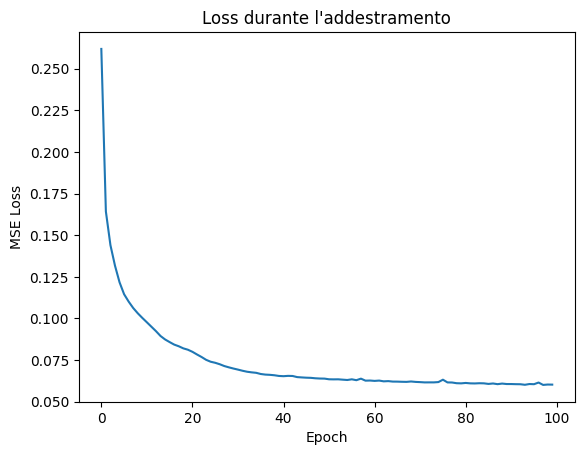


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [7]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)

#### Mix Tanh

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2573
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1575
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1357
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1215
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1127
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1062
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1010
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0967
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0930
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0901
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0875
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0850
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0833
Epoch 14/100
107/107 ━━━━━━━

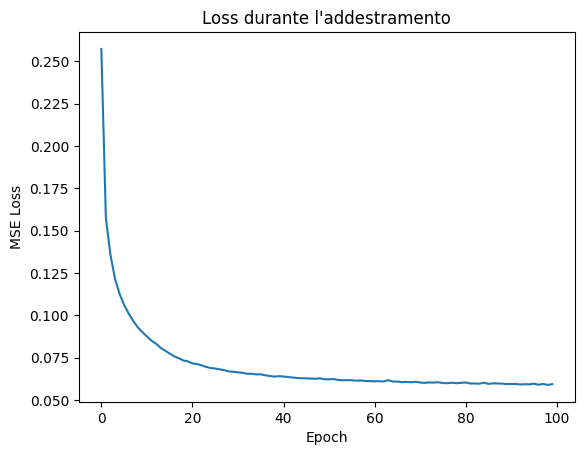


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [8]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)

#### Relu

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2617
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1584
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1333
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1223
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1152
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1097
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1054
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1014
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0970
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0932
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0896
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0872
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0855
Epoch 14/100
107/107 ━━━━━━━━

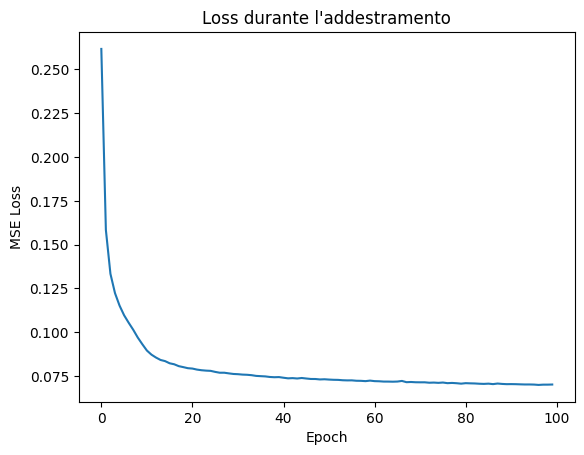


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [9]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)

#### Tanh

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2331
Epoch 2/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1512
Epoch 3/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1288
Epoch 4/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1174
Epoch 5/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1098
Epoch 6/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1044
Epoch 7/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1003
Epoch 8/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0968
Epoch 9/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0943
Epoch 10/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0919
Epoch 11/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0908
Epoch 12/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0894
Epoch 13/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0882
Epoch 14/200
107/107 ━━━━━━━

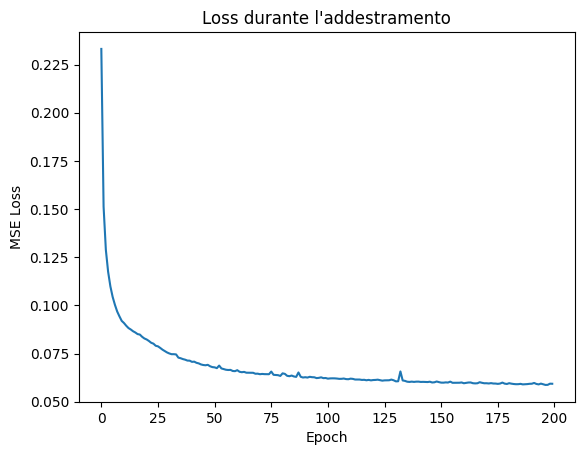


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [10]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU + tanh per un po' di non linearità in più)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)

#### ReLU with droput

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.2534
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1787
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1669
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1590
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1510
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1446
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1414
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1400
Epoch 9/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1372
Epoch 10/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1339
Epoch 11/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1323
Epoch 12/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1297
Epoch 13/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1280
Epoch 14/300
107/107 ━━━━━━━

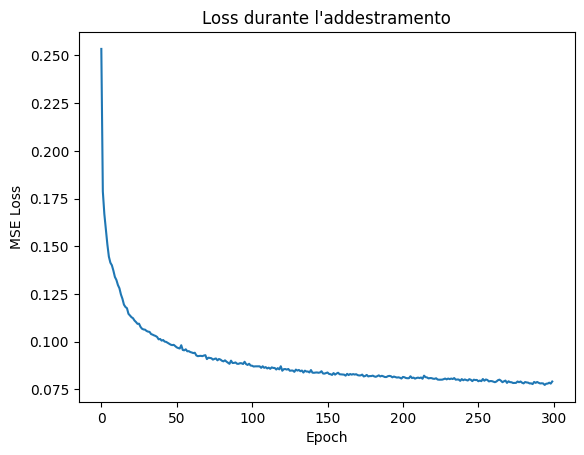


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [11]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)

#### Tanh with Droput

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.2185
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1550
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1420
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1346
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1286
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1237
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1214
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1190
Epoch 9/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1167
Epoch 10/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1140
Epoch 11/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1124
Epoch 12/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1121
Epoch 13/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1103
Epoch 14/300
107/107 

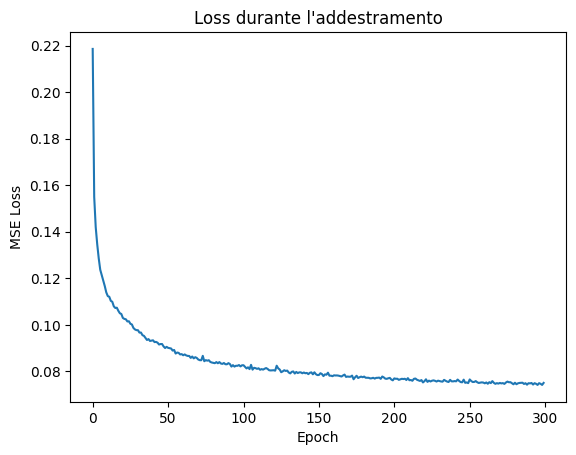


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [12]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con tanh)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

#### ReLU + Tanh on bottleneck and droput

--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---

Addestramento in corso...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2844
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1935
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1791
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1710
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1659
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1612
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1553
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1503
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1471
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1430
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1411
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1387
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1370
Epoch 14/100
107/107 ━━━━━━━━

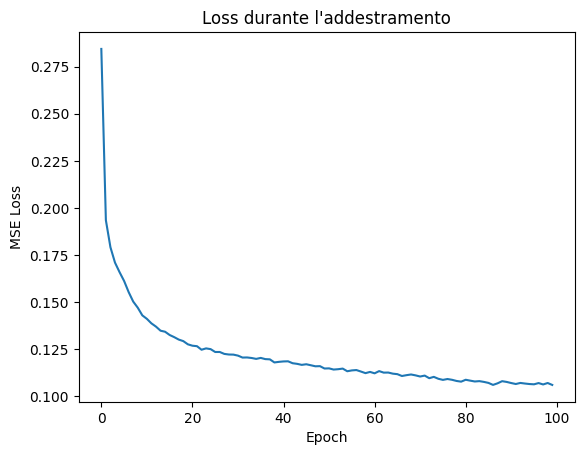


Estrazione del DNA a 10 dimensioni in corso...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [13]:
print("--- Costruzione Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. COSTRUZIONE DELL'ARCHITETTURA 
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (Compressione con attivazione ReLU)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (Il nostro Spazio Latente a 10 dimensioni)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Ricostruzione)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Output finale (Torna al numero di colonne originali, lineare)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
# Uniamo l'input all'output per creare il modello completo
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Usiamo 'adam' (ottimo e veloce in Keras) e l'errore quadratico medio
autoencoder.compile(optimizer='adam', loss='huber')

print("\nAddestramento in corso...")
# Addestriamo la rete (verbose=1 mostra una comoda barra di caricamento)
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Addestramento completato!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Loss durante l\'addestramento')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ==========================================
# 3. ESTRAZIONE DELLO SPAZIO LATENTE
# ==========================================
print("\nEstrazione del DNA a 10 dimensioni in corso...")

# Creiamo un SECONDO modello che si ferma al bottleneck
encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# ==========================================
# 4. MOTORE DI RICERCA (Similarity Search)
# ==========================================
# Creiamo il DataFrame con le 10 nuove coordinate estratte dall'IA
colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=colonne_ae)

# Uniamo l'anagrafica dei giocatori al loro nuovo "DNA"
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)

#### Testing Autonecoder

##### Similarity Function

In [14]:
def trova_simili_ae(nome_giocatore, stagione_giocatore, df_latente, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Cerchiamo l'indice del giocatore per nome e stagione
    mask_target = (
        (df_latente['player'].str.lower() == nome_giocatore.lower())
        & (df_latente['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente[mask_target].index
    
    if len(giocatore_idx) == 0:
        return "Giocatore non trovato nel database."
    
    idx = giocatore_idx[0]
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    stagione = df_latente.loc[idx, 'season']
    ruolo = df_latente.loc[idx, 'pos']
    
    print(f"\n[AUTOENCODER] Ricerca cloni per: {giocatore_reale} ({squadra_reale} - {stagione})")
    
    # Estraiamo i 10 numeri del giocatore cercato
    giocatore_vettore = df_latente.loc[idx, colonne_ae].values.reshape(1, -1)
    # Estraiamo i 10 numeri di TUTTI i giocatori
    tutti_i_vettori = df_latente[colonne_ae].values
    
    # Calcoliamo la Similarità Coseno
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]
    
    # Assegniamo i punteggi
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita
    
    # Escludiamo il giocatore target dai risultati
    df_latente_temp = df_latente_temp.drop(index=idx)
    
    # Filtro opzionale per età
    if max_age is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['age'] <= max_age]
    
    # Filtro opzionale per stagione
    if season_filter is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['season'] == season_filter]
    
    # Filtro opzionale per ruolo
    if same_position:
        df_latente_temp = df_latente_temp[df_latente_temp['pos'] == ruolo]
    
    # Filtro opzionale per lega
    if same_league:
        df_latente_temp = df_latente_temp[df_latente_temp['league'] == df_latente.loc[idx, 'league']]
    
    # Filtro opzionale per piede preferito
    if same_preferred_foot:
        df_latente_temp = df_latente_temp[df_latente_temp['preferred_foot'] == df_latente.loc[idx, 'preferred_foot']]
    
    df_latente_temp = df_latente_temp[df_latente_temp['player'] != nome_giocatore]
    
    # Ordiniamo dal più simile al meno simile
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    
    # Formattiamo la colonna in percentuale per renderla leggibile
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'
    
    colonne_output = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return simili[colonne_output]

In [16]:
def trova_simili_ensemble(
    nome_giocatore,
    stagione_giocatore,
    df_latente_a=df_latent_ae_relu_tanh_btn,
    df_latente_b=df_latent_ae_tanh_dropout,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (df_latente_a['player'].str.lower() == nome_giocatore.lower())
        & (df_latente_a['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente_a[mask_target].index

    if len(giocatore_idx) == 0:
        return "Giocatore non trovato nel database."

    idx = giocatore_idx[0]
    giocatore_reale = df_latente_a.loc[idx, 'player']
    squadra_reale = df_latente_a.loc[idx, 'team']
    stagione = df_latente_a.loc[idx, 'season']
    ruolo = df_latente_a.loc[idx, 'pos']
    league = df_latente_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Ricerca cloni per: {giocatore_reale} ({squadra_reale} - {stagione})")

    # Average cosine similarity from the two latent spaces
    vettore_a = df_latente_a.loc[idx, colonne_ae].values.reshape(1, -1)
    vettore_b = df_latente_b.loc[idx, colonne_ae].values.reshape(1, -1)

    sim_a = cosine_similarity(vettore_a, df_latente_a[colonne_ae].values)[0]
    sim_b = cosine_similarity(vettore_b, df_latente_b[colonne_ae].values)[0]
    sim_ensemble = (sim_a + sim_b) / 2

    df_temp = df_latente_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == ruolo]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != nome_giocatore]

    simili = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

##### Testing

###### Single Testing

In [17]:
# ==========================================
# 5. TESTIAMO IL MODELLO
# ==========================================
target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'Relu' : df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    'Mix ReLU': df_latent_ae_mix_relu,
    'Mix Tanh': df_latent_ae_mix_tanh,
    'ReLu + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Modello: {model_name} =====")
    risultati_ae = trova_simili_ae(
        nome_giocatore=target_player,
        stagione_giocatore=target_season,
        df_latente=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(risultati_ae)

print("\n===== Modello: Ensemble =====")
risultati_ensemble = trova_simili_ensemble(
    nome_giocatore=target_player,
    stagione_giocatore=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(risultati_ensemble)


===== Modello: Relu =====

[AUTOENCODER] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,99.6%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,99.1%
1293,Jean-Philippe Mateta,26,Crystal Palace,FW,ENG-Premier League,2023 - 2024,99.1%
952,Santiago Castro,19,Bologna,FW,ITA-Serie A,2024 - 2025,99.1%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,99.0%



===== Modello: Tanh =====

[AUTOENCODER] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,91.0%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,85.2%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,83.6%
287,Julián Álvarez,24,Atlético Madrid,FW,ESP-La Liga,2024 - 2025,83.0%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,81.8%



===== Modello: Mix ReLU =====

[AUTOENCODER] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


...

,player,age,team,pos,league,season,Match %
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,91.5%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,88.5%
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,88.3%
2059,Justin Njinmah,22,Werder Bremen,FW,GER-Bundesliga,2023 - 2024,86.7%
2835,Terem Moffi,23,Lorient,FW,FRA-Ligue 1,2022 - 2023,86.5%



===== Modello: ReLU + Tanh bottleneck =====

[AUTOENCODER] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,95.5%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,89.4%
3153,Niclas Füllkrug,29,Werder Bremen,FW,GER-Bundesliga,2022 - 2023,86.4%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,83.1%
2212,Federico Chiesa,25,Juventus,FW,ITA-Serie A,2023 - 2024,82.9%



===== Modello: Ensemble =====

[ENSEMBLE] Ricerca cloni per: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,91.9%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,85.3%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,83.9%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,82.5%
2059,Justin Njinmah,22,Werder Bremen,FW,GER-Bundesliga,2023 - 2024,81.3%


###### Bulk Testing

In [18]:
# Tabella unica con tutti i risultati (giocatore target x modello)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for giocatore in target:
    for model_name, model_df in models_to_test.items():
        res = trova_simili_ae(
            nome_giocatore=giocatore,
            stagione_giocatore=target_season,
            df_latente=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[giocatore],
            same_league=False,
            same_preferred_foot=False
        )
        
        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = giocatore
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Aggiunge anche il risultato del modello Ensemble
    res_ensemble = trova_simili_ensemble(
        nome_giocatore=giocatore,
        stagione_giocatore=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[giocatore],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = giocatore
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# DataFrame finale "grouped"
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Ordine colonne per leggibilità
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE] Ricerca cloni per: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Ricerca cloni per: Alessandro Ba

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Jules Koundé,23,Barcelona,DF,ESP-La Liga,2022 - 2023,92.1%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Riccardo Calafiori,21,Bologna,DF,ITA-Serie A,2023 - 2024,83.9%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Angelo Stiller,22,Stuttgart,MF,GER-Bundesliga,2023 - 2024,83.7%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Piero Hincapié,22,Leverkusen,DF,GER-Bundesliga,2024 - 2025,83.4%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Facundo Medina,23,Lens,DF,FRA-Ligue 1,2022 - 2023,81.4%
...,...,...,...,...,...,...,...,...,...,...,...
275,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Matìas Soulé,21,Roma,"MF,DF",ITA-Serie A,2024 - 2025,90.8%
276,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Phil Foden,22,Manchester City,FW,ENG-Premier League,2022 - 2023,90.0%
277,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Paul Nebel,21,Mainz 05,MF,GER-Bundesliga,2024 - 2025,88.8%
278,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Vitinha,23,Paris S-G,MF,FRA-Ligue 1,2023 - 2024,88.4%


In [19]:
grouped_results_table.to_csv("grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances (e.g., hybrid roles, statistical outliers), the final pipeline utilizes an Ensemble Learning approach, averaging the similarity scores of two distinct neural network architectures.

* Model A: The "Specialist" (ReLU + Tanh Bottleneck)
    * Architecture: Standard
            
            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output.

    * Encoder/Decoder Activation (ReLU): Induces sparsity. It zeroes out irrelevant stats (noise), allowing the network to focus strictly on a player's core traits without being distracted by tasks they rarely perform.
    * Bottleneck Activation (Tanh): Forces the 10D latent representation into a dense, bounded space [-1, 1]. Eliminating zeros in the latent space ensures optimal conditions for calculating Cosine Similarity angles.
    * Epochs & Batch Size: 100 epochs, batch size 32 (optimized for fast convergence on tabular data without overfitting).

* Model B: The "Holistic" (Mix Tanh Deeper)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships 
    
            Input -> 64 -> 56 -> 48 -> 40 -> 32 -> 24 -> 16 -> 10 -> 16 -> 24 -> 32 -> 40 -> 48 -> 56 -> 64 -> Output
    
    * Activation (Tanh throughout): No neurons are turned off. A negative match outputs -1, actively penalizing players who lack a specific required trait. This model evaluates the "whole package" and excels at finding hybrid profiles (e.g., ball-playing center-backs or inverted wingers).
    * Epochs & Batch Size: 100 epochs, batch size 32 (optimized for fast convergence on tabular data without overfitting).

* Training Hyperparameters (Both Models)
    * Loss Function - Huber: A hybrid between MSE and MAE. It is robust to statistical outliers (e.g., players like Haaland or De Bruyne with abnormal stats) preventing the model from obsessing over extreme values, while remaining highly precise for average data points.
    * Optimizer: Adam
    * Rationale: Standard, highly efficient adaptive gradient descent.
    

* The Ensemble Strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B) / 2
    * Rationale: Model A is highly precise but can be rigid; Model B is tactically creative but can occasionally drift. Averaging their raw Cosine Similarity scores stabilizes the output. It boosts players recognized by both architectures while penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* NEXT STEP: add gps data to better understand the position of the player


## Anomaly Detection

### SVM

### Autoencoder Reconstruction Error

## End

In [20]:
end_time = time.time()

In [21]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTempo totale di esecuzione: {elapsed_minutes:.0f}.{remaining_seconds:.0f}  min ")


Tempo totale di esecuzione: 17.13  min 
